Кейс №1 - Приложение знакомств

Вы работаете аналитиком в приложении для онлайн-знакомств. Механика приложения следующая: пользователи видят в приложении анкеты друг друга и могут ставить друг другу лайки или дизлайки. Если пользователи поставили друг другу лайк – это называется мэтч, и у пользователей появляется возможность познакомиться.

Команда приложения разработала новый алгоритм для поиска наиболее подходящих анкет. Для проверки работы алгоритма был проведен АБ-тест. Все пользователи были разделены на две группы. Пользователи в группе с номером 0 пользовались приложением со старым алгоритмом. Все пользователи в группе 1 пользовались приложением с новым алгоритмом для поиска анкет.

Ваша задача – оценить, правда ли, что новый алгоритм улучшил качество сервиса. Для этого нужно выбрать метрики, которые отвечают за качество сервиса, и статистически сравнить эти метрики в двух группах.

In [52]:
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency, chi2 
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import seaborn as sns
from statsmodels.stats.multicomp import (pairwise_tukeyhsd,
                                         MultiComparison) 
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [14]:
dating_data = pd.read_csv('C://Users//Admin//Desktop//Devs//anal//dating_data.csv')

In [15]:
dating_data.head()

,user_id_1,user_id_2,group,is_match
0,79,91,1,1
1,716,353,1,1
2,423,677,0,0
3,658,165,1,1
4,969,155,0,1


In [20]:
dating_data.dtypes #проверка типоа данных

user_id_1    int64
user_id_2    int64
group        int64
is_match     int64
dtype: object

In [24]:
dating_data.isna().sum() #проверка пропущеных значений

user_id_1    0
user_id_2    0
group        0
is_match     0
dtype: int64

проверим, есть ли пользователи, которые попали одновременны в обе группы

In [32]:
dating_data0 = dating_data.query("group==0")
dating_data0.head() 

,user_id_1,user_id_2,group,is_match
2,423,677,0,0
4,969,155,0,1
5,227,162,0,0
8,223,295,0,0
10,825,388,0,0


In [33]:
dating_data1 = dating_data.query("group==1")
dating_data1.head() 

,user_id_1,user_id_2,group,is_match
0,79,91,1,1
1,716,353,1,1
3,658,165,1,1
6,435,16,1,0
7,602,327,1,0


In [54]:
#пользователи первой группы
group0_list = list(set(dating_data0.user_id_1.tolist() + (dating_data0.user_id_2.tolist())))
len(group0_list)

501

In [56]:
#пользователи второй группы
group1_list = list(set(dating_data1.user_id_1.tolist() + (dating_data1.user_id_2.tolist())))
len(group1_list)

499

In [57]:
#проверим, есть ли пользователи, которые попали одновременны в обе группы
#таких пользователей нет
np.intersect1d(group0_list, group1_list)

array([], dtype=int32)

In [84]:
dating_data0_group = dating_data0\
    .groupby('user_id_1',as_index = False)\
    .agg({'is_match': 'sum'})
dating_data0_group.head()

,user_id_1,is_match
0,4,2
1,10,3
2,12,1
3,14,0
4,15,3


In [85]:
dating_data1_group = dating_data1\
    .groupby('user_id_1',as_index = False)\
    .agg({'is_match': 'sum'})
dating_data1_group.head()

,user_id_1,is_match
0,1,11
1,2,7
2,3,5
3,5,13
4,6,9


In [46]:
dating_data0_group.is_match.var()

1.8535409181636726

In [47]:
dating_data1_group.is_match.var()

6.159024877063378

Дисперcия в тестовой и контрольной группе сильно различается, следовательно Т-тест применять нельзя

Посмотрим колиичественные значения числа мэтчей

<Axes: xlabel='group', ylabel='Count'>

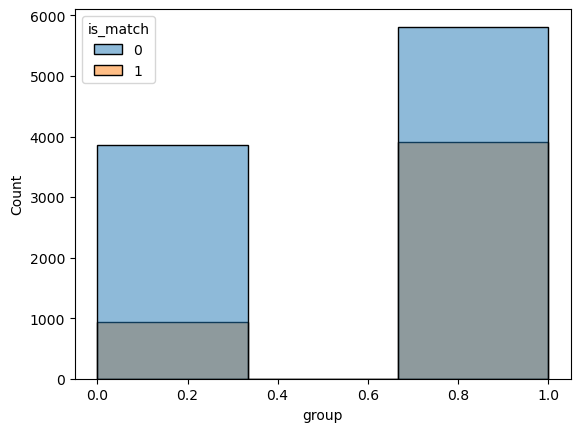

In [48]:
sns.histplot(data=dating_data, x='group', hue='is_match', bins=3) #второй алгоритм кажктся лучше

In [50]:
pd.crosstab(dating_data.is_match, dating_data.group)

group,0,1
is_match,,
0,3858,5813
1,934,3909


In [53]:
chi2_contingency(pd.crosstab(dating_data.is_match, dating_data.group))

Chi2ContingencyResult(statistic=618.6889141576197, pvalue=1.441829916366341e-136, dof=1, expected_freq=array([[3193.01584677, 6477.98415323],
       [1598.98415323, 3244.01584677]]))

p-value < 0,05 - опровергаем нулевую гипотезу - следовательно различия статистически значимые.

Мы с уверенностью можем говорить, что при использовании нового алгоритма мэтчи происходят чаще

Теперь посмотрим как в среднем меняется конверсия у пользователей

In [89]:
a = dating_data0[['user_id_1', 'is_match']].rename(columns={'user_id_1': 'user_id'})
b = dating_data0[['user_id_2', 'is_match']].rename(columns={'user_id_2': 'user_id'})
group0 = a.append(b)
convers0 = group0.groupby('user_id', as_index=False).agg({'is_match': 'mean'})

C:\Users\Admin\AppData\Local\Temp\ipykernel_14784\4188412306.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  group0 = a.append(b)


In [90]:
a = dating_data1[['user_id_1', 'is_match']].rename(columns={'user_id_1': 'user_id'})
b = dating_data1[['user_id_2', 'is_match']].rename(columns={'user_id_2': 'user_id'})
group1 = a.append(b)
convers1 = group1.groupby('user_id', as_index=False).agg({'is_match': 'mean'})

C:\Users\Admin\AppData\Local\Temp\ipykernel_14784\2026388820.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  group1 = a.append(b)


In [92]:
convers1

,user_id,is_match
0,1,0.432432
1,2,0.410256
2,3,0.320000
3,5,0.529412
4,6,0.411765
...,...,...
494,987,0.414634
495,992,0.400000
496,993,0.439024
497,998,0.500000


C:\Users\Admin\AppData\Local\Temp\ipykernel_14784\3716840673.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(convers0.is_match)
C:\Users\Admin\AppData\Local\Temp\ipykernel_14784\3716840673.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(convers1.is_match)


<Axes: xlabel='is_match', ylabel='Density'>

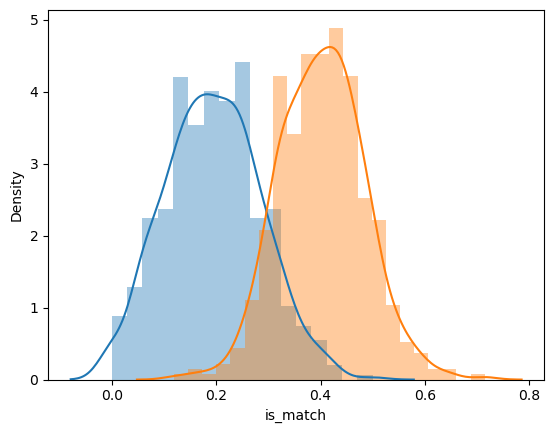

In [93]:
sns.distplot(convers0.is_match)
sns.distplot(convers1.is_match)

На графике видны различия, средняя конверсия у пользователей группы 1 больше средней конверсии пользователей группы 0.

Нужно понять, являются ли эти различия статистически значимыми.

H1 - средняя конверсия метчей зависит от группы (использование нового алгоритма увеличило среднюю конверсию мэтчей)

H0 - средняя конверсия метчей не зависит от группы (новый алгоритм никак не повлиял на среднюю конверсию мэтчей)

Оба распределения являются нормальными, не имеют экстиральных выбросов поэтому я буду использовать двухвыботочный t-тест

In [96]:
stats.ttest_ind(convers0.is_match, convers1.is_match)

Ttest_indResult(statistic=-38.2345905275919, pvalue=1.0344736796459191e-197)

p-value < 0.05 - отклоняем нулевую гипотезу - следовательно различия между средними значаниями конверсии в двух группах статистически значимы

Я делаю вывод что новый алгоритм работает лучше старого.